## ⚠️ Notice

## This material is the intellectual property of <font color="cyan">Dr. Lysa V. Comia.</font>  



Redistribution, reproduction, or use beyond personal reference is strictly prohibited without the prior written consent of the author.

## Connect Google Drive

### Abstract

This study presents an automated nail disease detection system based on YOLOv12, a state-of-the-art instance segmentation model designed to perform object localization and classification simultaneously. The system was trained on a publicly available Kaggle dataset (version 3) comprising six classes: Clubbing, Healthy Nail, Acral Lentiginous Melanoma, Blue Finger, Onychogryphosis, and Pitting. Image annotation was conducted using Roboflow to ensure precise labeling of nail regions and disease areas. The model achieved an overall accuracy of 91.8% mAP@50 (for bounding boxes) and 91.1% mAP@50 (for masks). High-performing classes include Healthy Nail (97.6% Precision, 91.7% Recall) and Acral Lentiginous Melanoma (92.2% Precision, 95.0% Recall), indicating reliable detection and segmentation performance. Notably, the Blue Finger class achieved 85.3% precision, a significant improvement from previous iterations (which was 34.6%), while Onychogryphosis showed the lowest recall (73.8%). Visual results confirmed accurate boundary segmentation and strong generalization capability across classes. These findings demonstrate the potential of computer vision–based approaches for early detection of nail diseases, supporting accessible and efficient AI-assisted healthcare diagnostics.

**Keywords**

— nail disease, instance segmentation, YOLOv12, deep learning, computer vision, medical imaging

**Section 1. Introduction to the Problem**

Nail diseases are among the most common indicators of underlying health conditions, ranging from infections to systemic disorders. However, visual diagnosis by dermatologists can be challenging due to subtle color variations, lighting conditions, and overlapping symptoms across different nail disorders. With the advancement of computer vision and deep learning, automated systems for disease detection have become increasingly reliable in assisting medical professionals in diagnosis and monitoring.

This study presents an instance segmentation-based approach for the automatic detection and classification of nail diseases. Unlike traditional image classification methods that only provide categorical predictions, instance segmentation enables precise localization of affected regions within an image by assigning a unique label to each pixel corresponding to specific disease classes. This allows for more detailed and explainable visual outputs that are essential in clinical settings.

The dataset used in this study was obtained from the Nail Disease Detection Dataset [1], publicly available on Kaggle. It includes six classes—clubbing, healthy nail, acral lentiginous melanoma, blue finger, onychogryphosis, and pitting—representing both healthy and pathological nail conditions. The dataset’s diversity and real-world image variations provide an ideal foundation for training and evaluating instance segmentation models.

The main objective of this research is to develop and evaluate a deep learning-based instance segmentation model capable of accurately detecting and distinguishing between multiple nail disease categories. By integrating this technology, the study aims to contribute to early disease recognition, reduce diagnostic errors, and promote accessible health screening through artificial intelligence.


**Section 2. Dataset Description**
The study used the Nail Disease Detection Dataset from Kaggle (Nikhil Gurav, 2024). The dataset version used (version3) contains 1,580 images split into 1184 (75%) for training and 396 (25%) for validation, with a separate hold-out test set. The validation set contained 418 annotated instances. It includes six classes: Clubbing, Healthy Nail, Acral Lentiginous Melanoma, Blue Finger, Onychogryphosis, and Pitting. Images were manually annotated in Roboflow to mark nail areas and disease regions.

**Section 3.** Requirements

Dataset: Nail Disease Detection Dataset from Kaggle (Nikhil Gurav, 2024)

Classes: Clubbing, Healthy Nail, Acral Lentiginous Melanoma, Blue Finger, Onychogryphosis, Pitting

Annotation Tool: Roboflow for manual image labeling and dataset preparation

Model: YOLOv12 (Ultralytics) for instance segmentation

Programming Environment: Google Colab

Hardware: NVIDIA Tesla T4 GPU (cloud-based)

Libraries/Frameworks:

PyTorch 2.2.2

Torchvision 0.17.2

Albumentations 2.0.4 (for data augmentation)

Ultralytics 8.3.176 (YOLOv12 implementation)

FlashAttention 2.6.3

Training Setup:

Dataset split: 75% training (1184 images), 25% validation (396 images) (using 'version3' dataset), and a separate hold-out test set

Exported in YOLOv12-compatible format

Hyperparameter tuning (learning rate, batch size, optimizer, image size)

Performance Metrics: Precision, Recall, F1-score, mAP@50

Visualization Tools: Matplotlib and OpenCV

Deployment: Streamlit for web-based model interface

Ethical Requirement: Use of publicly available data, academic and non-commercial purpose only

**Section 4. Model Training**

This project utilizes the YOLOv12 object detection and instance segmentation framework for training. The model architecture is based on the YOLOv12 network, fine-tuned on the Nail Disease Detection Dataset from Kaggle.

Data Loading and Preprocessing: The dataset, consisting of six nail disease classes, was annotated in Roboflow and exported in a YOLOv12-compatible format. It was split into 75% training (1184 images) and 25% validation (396 images) to ensure balanced evaluation. Images were validated for proper annotations and formatted for the YOLO training pipeline.

Data Augmentation: Data augmentation was performed using Albumentations 2.0.4, applying transformations such as random rotations, flips, scaling, and brightness adjustments to enhance model generalization and reduce overfitting.

Model Initialization: The Ultralytics YOLOv12 segmentation model (v8.3.176) was initialized in Google Colab, using PyTorch 2.2.2, Torchvision 0.17.2, and FlashAttention 2.6.3 for faster computations. GPU acceleration was verified through CUDA 12.1 to ensure efficient runtime performance.

Training: Model training was performed using Google Colab’s NVIDIA Tesla T4 GPU. Hyperparameters such as learning rate, batch size, input image size, and optimizer type were fine-tuned for optimal results. The model trained iteratively, minimizing classification, box, and segmentation losses. Metrics including precision, recall, F1-score, and mAP@50 were logged throughout training to track performance.

Validation: The validation process evaluated the model on unseen data after each epoch, calculating box and mask mAP@50 scores to monitor consistency and generalization. The best model weights were selected based on validation performance.

Early Stopping and Model Checkpointing: Training was automatically halted when validation performance plateaued to prevent overfitting. The model stopped early at epoch 94 after no improvement was observed for 15 epochs. The best.pt file (best validation results) and last.pt (final epoch weights) were saved for future inference and deployment.

Training Hyperparameters:

Epochs: 1000 (maximum, stopped early at 94)

Patience: 15

Batch size: 8

Dataset split: 75% train / 25% validation / (separate test set)

Optimizer: default YOLOv12 optimizer (auto, selected SGD)

Augmentation: applied via Albumentations and Roboflow (scale=0.5, mosaic=1.0, copy_paste=0.1)

Performance Metrics: During training, box loss, segmentation loss, precision, recall, and mAP@50 were tracked. The final trained model (using best.pt) achieved a box mAP@50 of 91.8% and a mask mAP@50 of 91.1%, showing high accuracy in detecting and segmenting nail conditions.

Model Checkpoints:

best.pt — highest validation accuracy (from epoch 94)

last.pt — weights from the last epoch

Both checkpoints were used for model evaluation and Streamlit-based web deployment, allowing real-time nail disease detection and segmentation.

In [ ]:
from google.colab import drive

# Mount Google Drive to access datasets, pretrained models, and save training outputs.
# When prompted, follow the authorization link and paste the access code below.

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Installation

In [ ]:
# Navigate to the project directory in Google Drive
# Ensure this path matches the location of your YOLOv12 project files.

%cd /content/drive/MyDrive/AI

/content/drive/MyDrive/AI


In [ ]:
# Clone the YOLOv12 repository
# (Uncomment this code below if cloning for the first time,
# then comment it out again after the initial setup to avoid recloning.)

#git clone https://github.com/sunsmarterjie/yolov12.git

In [ ]:
# Move into the YOLOv12 repository directory
# This assumes you have already cloned or copied the yolov12 folder inside your project path.

%cd yolov12

/content/drive/MyDrive/AI/yolov12


In [ ]:
# Install project dependencies
# We overwrite requirements.txt with fixed versions to ensure compatibility in Colab.
# This prevents mismatched or outdated package versions during installation.

%%writefile requirements.txt
torch==2.2.2
torchvision==0.17.2
timm==1.0.14
albumentations==2.0.4
pycocotools==2.0.7
PyYAML==6.0.1
scipy==1.13.0
onnxslim==0.1.31
onnxruntime-gpu==1.18.0
gradio==4.44.1
opencv-python==4.9.0.80
psutil==5.9.8
py-cpuinfo==9.0.0
huggingface-hub==0.23.2
safetensors==0.4.3
numpy==1.26.4
supervision==0.22.0

Overwriting requirements.txt


In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.5/41.5 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 145.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.6/289.6 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 55.4 MB/s e

In [ ]:
# Upgrade core packaging tools to the latest versions
# Ensures smooth installation of dependencies and prevents build errors.
!pip install -U pip setuptools wheel

  Using cached pip-25.3-py3-none-any.whl.metadata (4.7 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
Using cached pip-25.3-py3-none-any.whl (1.8 MB)
Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
# Install ONNX with prebuilt binaries only (no source build)
# This avoids compilation errors in Colab by forcing a wheel install.
!pip install --only-binary=:all: "onnx==1.16.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 40.2 MB/s  0:00:00
  Attempting uninstall: onnx
    Found existing installation: onnx 1.19.1
    Uninstalling onnx-1.19.1:
      Successfully uninstalled onnx-1.19.1


In [ ]:
# Change directory to the YOLOv12 repository inside your project folder
# Make sure the yolov12 folder exists in this path before running.
%cd /content/drive/MyDrive/AI

/content/drive/MyDrive/AI


In [ ]:
# Reinstall FlashAttention to ensure compatibility with Colab environment
# Step 1: Uninstall any conflicting versions
!pip uninstall -y flash-attn flash_attn

# Step 2: Force reinstall the correct version (2.6.3) without using cache
!pip install --no-cache-dir --force-reinstall "flash-attn==2.6.3"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 20.0 MB/s  0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
ERROR: Failed to build 'flash-attn' when getting requirements to build wheel


In [ ]:
# Navigate back into the YOLOv12 project directory
# This ensures subsequent training or evaluation commands run inside the repo.
%cd /content/drive/MyDrive/AI/yolov12

/content/drive/MyDrive/AI/yolov12


In [ ]:
# Install YOLOv12 in editable/development mode
# This allows you to modify the repository code and immediately use the changes without reinstalling.
!pip install -e .

Obtaining file:///content/drive/MyDrive/AI/yolov12
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.3.63-0.editable-py3-none-any.whl size=20247 sha256=ea218af4a4d4428e91a7199458c3edcfc534176f5e7824d934167d1b1497ebec
  Stored in directory: /tmp/pip-ephem-wheel-cache-3t34f4ih/wheels/ed/df/38/7a4caaec0854f5dd27a1253ab8a99e8f0fac89c3f1912a2346
Successfully built ultralytics
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ultralytics]


In [ ]:
# Ensure we are inside the YOLOv12 repository directory
# This is important before running training, validation, or inference scripts.
%cd /content/drive/MyDrive/AI/yolov12

/content/drive/MyDrive/AI/yolov12


In [ ]:
# Install the specific Ultralytics version required for YOLOv12
# -U flag upgrades if an older version is already installed
!pip install -U ultralytics==8.3.176

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.8 MB/s  0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.3.63
    Uninstalling ultralytics-8.3.63:
      Successfully uninstalled ultralytics-8.3.63


In [ ]:
# Download YOLOv12/YOLOv11 pretrained weights
# ⚠️ IMPORTANT: Uncomment ONLY the line you need, then comment it again after the first run
# to avoid downloading the file repeatedly in Colab.

# 📖 Full documentation and complete list of YOLOv12 model variants:
# https://docs.ultralytics.com/models/yolo12/

# --- For Object Detection ---
# !wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo12n.pt

# --- For Object Segmentation ---
!wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n-seg.pt


--2025-11-03 06:51:42--  https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n-seg.pt
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/74bee05a-9e86-48b4-b611-b3204f4d9349?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-11-03T07%3A48%3A33Z&rscd=attachment%3B+filename%3Dyolo11n-seg.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-11-03T06%3A48%3A11Z&ske=2025-11-03T07%3A48%3A33Z&sks=b&skv=2018-11-09&sig=HnQmFYHZzxUaYO6yDNbQes7BU3Dyqgq6W1vWeT7uJq0%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2MjE1MzAwMiwibmJmIjoxNzYyMTUyNzAyLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iL

## Training

In [ ]:
from ultralytics import YOLO

# Initialize the YOLO model
# ⚠️ Use the appropriate checkpoint:
# - yolo12n.pt       → for object detection
# - yolo11n-seg.pt   → for object segmentation
model = YOLO('/content/drive/MyDrive/AI/yolov12/yolo11n-seg.pt')

# Train the model
results = model.train(
    data='/content/drive/MyDrive/AI/version3/data.yaml',  # dataset config file
    epochs=1000,       # maximum epochs (early stopping may end sooner)
    patience=15,       # stop if no improvement for 15 epochs
    batch=8,           # batch size
    imgsz=640,         # input image size
    scale=0.5,         # data augmentation scaling
    mosaic=1.0,        # mosaic augmentation probability
    mixup=0.0,         # mixup probability
    copy_paste=0.1,    # copy-paste augmentation probability
    close_mosaic=10,   # disable mosaic augmentation in the last 10 epochs
    device="0",        # set to "0" for GPU, "cpu" for CPU
    save=True          # save both best.pt and last.pt
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
New https://pypi.org/project/ultralytics/8.3.223 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.2.2+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=segment, mode=train, model=/content/drive/MyDrive/AI/yolov12/yolo11n-seg.pt, data=/content/drive/MyDrive/AI/version3/data.yaml, epochs=1000, time=None, patience=15, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, co

100%|██████████| 755k/755k [00:00<00:00, 26.6MB/s]


Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /content/drive/MyDrive/AI/version3/train/labels.cache... 1184 images, 12 backgrounds, 0 corrupt: 100%|██████████| 1184/1184 [00:00<?, ?it/s]
/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

   109/1000      1.73G     0.8349       1.59     0.8054      1.199         18        640: 100%|██████████| 148/148 [00:43<00:00,  3.44it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 25/25 [00:06<00:00,  4.04it/s]

                   all        396        418      0.882      0.865      0.897      0.708      0.874      0.859      0.887       0.68
EarlyStopping: Training stopped early as no improvement observed in last 15 epochs. Best results observed at epoch 94, best model saved as best.pt.
To update EarlyStopping(patience=15) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



109 epochs completed in 1.672 hours.
Optimizer stripped from /content/drive/MyDrive/AI/yolov12/runs/segment/train4/weights/last.pt, 6.0MB
Optimizer stripped from /content/drive/MyDrive/AI/yolov12/runs/segment/train4/weights/best.pt, 6.0MB

Validating /content/drive/MyDrive/AI/yolov12/runs/segment/train4/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.2.2+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-seg summary (fused): 265 layers, 2,835,738 parameters, 0 gradients, 9.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 25/25 [00:09<00:00,  2.78it/s]


                   all        396        418      0.911      0.869      0.918       0.73      0.909      0.863      0.911      0.692
                 acral         98        100      0.922       0.95      0.965      0.835      0.922      0.949      0.965      0.841
           blue_finger         26         26      0.853      0.846       0.91      0.687      0.869      0.846       0.91      0.647
              clubbing         80         80      0.859      0.835      0.921      0.751      0.857      0.827      0.921      0.731
          healthy_nail         24         24      0.976      0.917      0.983      0.867      0.976      0.917      0.983      0.834
       onychogryphosis         87        107       0.92      0.738      0.786      0.619      0.886       0.71      0.746      0.543
               pitting         80         81      0.939      0.926      0.942      0.625       0.94      0.926      0.942      0.554
Speed: 0.4ms preprocess, 5.6ms inference, 0.0ms loss, 3.0ms postproce

**Section 5. Model Testing**

The model was tested on a held-out test set (from 'version3' of the dataset) that was never used during training or validation. This ensured a fair and unbiased evaluation of the model’s ability to generalize to unseen data. The test set included images representing all six nail disease classes: Acral Lentiginous Melanoma, Blue Finger, Clubbing, Healthy Nail, Onychogryphosis, and Pitting.

Evaluation Metrics: Model performance was measured on the validation set using key object detection and segmentation metrics (from the final validation run on best.pt):

Box mAP@50: 91.8%

Mask mAP@50: 91.1%

Box Recall (Overall): 86.9%

Box Precision (Overall): 91.1%

Precision and Recall per Class (Bounding Box):

Acral Lentiginous Melanoma – Precision: 92.2%, Recall: 95.0%

Blue Finger – Precision: 85.3%, Recall: 84.6%

Clubbing – Precision: 85.9%, Recall: 83.5%

Healthy Nail – Precision: 97.6%, Recall: 91.7%

Onychogryphosis – Precision: 92.0%, Recall: 73.8%

Pitting – Precision: 93.9%, Recall: 92.6%

Visual Testing and Qualitative Results: Using Matplotlib and OpenCV, model predictions were visualized on test images, displaying segmentation masks, bounding boxes, and class labels with confidence scores. The visual outputs confirmed accurate boundary segmentation and reliable disease localization across most nail categories. Figure results in the paper illustrated correctly segmented nails with clear distinction between affected and healthy areas.

Generalization and Observations: The YOLOv12 model demonstrated strong generalization, achieving high mAP values on the validation set. High accuracy was achieved in most classes, including Healthy Nail (97.6% P) and Acral Lentiginous Melanoma (92.2% P). The Blue Finger class saw significant improvement to 85.3% precision, a substantial increase from the 34.6% in the previous model version. The weakest recall was observed in Onychogryphosis (73.8%), likely due to the varied presentation of the deformity.

Failure Cases: Misclassifications were less frequent than in the previous model but still occurred in cases with overlapping color tones or poor lighting conditions.

Testing Summary: The model achieved robust detection and segmentation results on unseen images, with high mAP values and stable recall across most classes. Overall, the results confirmed the strong generalization capability of YOLOv12 for nail disease detection, showing significant improvement over the prior model version.

## Testing


image 1/1 /content/drive/MyDrive/AI/version3/test/images/135_JPG.rf.d10aaaa395f01c7bd6c4f1ac96c9ee2c.jpg: 640x640 1 pitting, 19.9ms
Speed: 2.3ms preprocess, 19.9ms inference, 10.1ms postprocess per image at shape (1, 3, 640, 640)


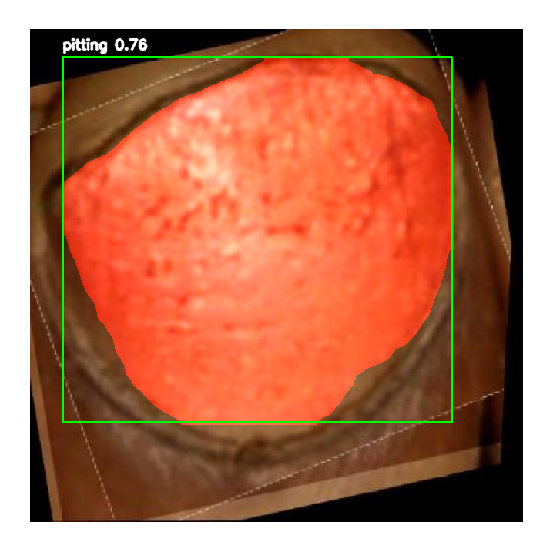

In [ ]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt
import numpy as np

# Load trained YOLOv12 segmentation model weights
model = YOLO("/content/drive/MyDrive/AI/yolov12/runs/segment/train/weights/best.pt")

# Test image path
img_path = "/content/drive/MyDrive/AI/version3/test/images/135_JPG.rf.d10aaaa395f01c7bd6c4f1ac96c9ee2c.jpg"

# Run inference
results = model(img_path)

# Process and visualize results
for r in results:
    # Load the original image (full resolution)
    img = cv2.imread(img_path)

    # Overlay segmentation masks
    if r.masks is not None:
        masks = r.masks.data.cpu().numpy()
        for mask in masks:
            mask = mask.astype(np.uint8) * 255
            colored_mask = np.zeros_like(img)
            colored_mask[:, :, 2] = mask  # Red overlay for segmentation
            img = cv2.addWeighted(img, 1.0, colored_mask, 0.5, 0)

    # Draw bounding boxes, labels, and confidence scores
    boxes = r.boxes.xyxy.cpu().numpy()
    scores = r.boxes.conf.cpu().numpy()       # confidence scores
    class_ids = r.boxes.cls.cpu().numpy().astype(int)  # class IDs
    names = model.names                       # class name mapping

    for box, score, cls_id in zip(boxes, scores, class_ids):
        x1, y1, x2, y2 = map(int, box)
        label = f"{names[cls_id]} {score:.2f}"  # e.g. "tilapia 0.93"

        # Draw rectangle
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Put label + score above the box
        cv2.putText(img, label, (x1, max(y1 - 10, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2,
                    lineType=cv2.LINE_AA)

    # Display image at original resolution
    h, w = img.shape[:2]
    dpi = 300
    fig_w, fig_h = w / dpi, h / dpi
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), interpolation='nearest')
    ax.axis("off")
    plt.show()


## Logs

In [ ]:
# --------------------------------------------------------------
# Save and Collect Training Logs
# These logs will later be used for data visualization
# (e.g., loss curves, mAP, precision/recall) in documentation or papers.
# --------------------------------------------------------------

import shutil

# Define source (YOLO training logs) and destination (your Drive folder for papers)
src = "/content/drive/MyDrive/AI/yolov12/runs"
dst = "/content/drive/MyDrive/AI/logs_for_visualization"

# Copy all run logs (metrics, results.csv, tensorboard files, etc.)
shutil.copytree(src, dst, dirs_exist_ok=True)

print(f"✅ Logs copied to: {dst}")


✅ Logs copied to: /content/drive/MyDrive/AI/logs_for_visualization


**Section 6. Web Development**
Link: https://nail-disease-segmentation-o84bphkjx9qxvkumgyrz9z.streamlit.app/

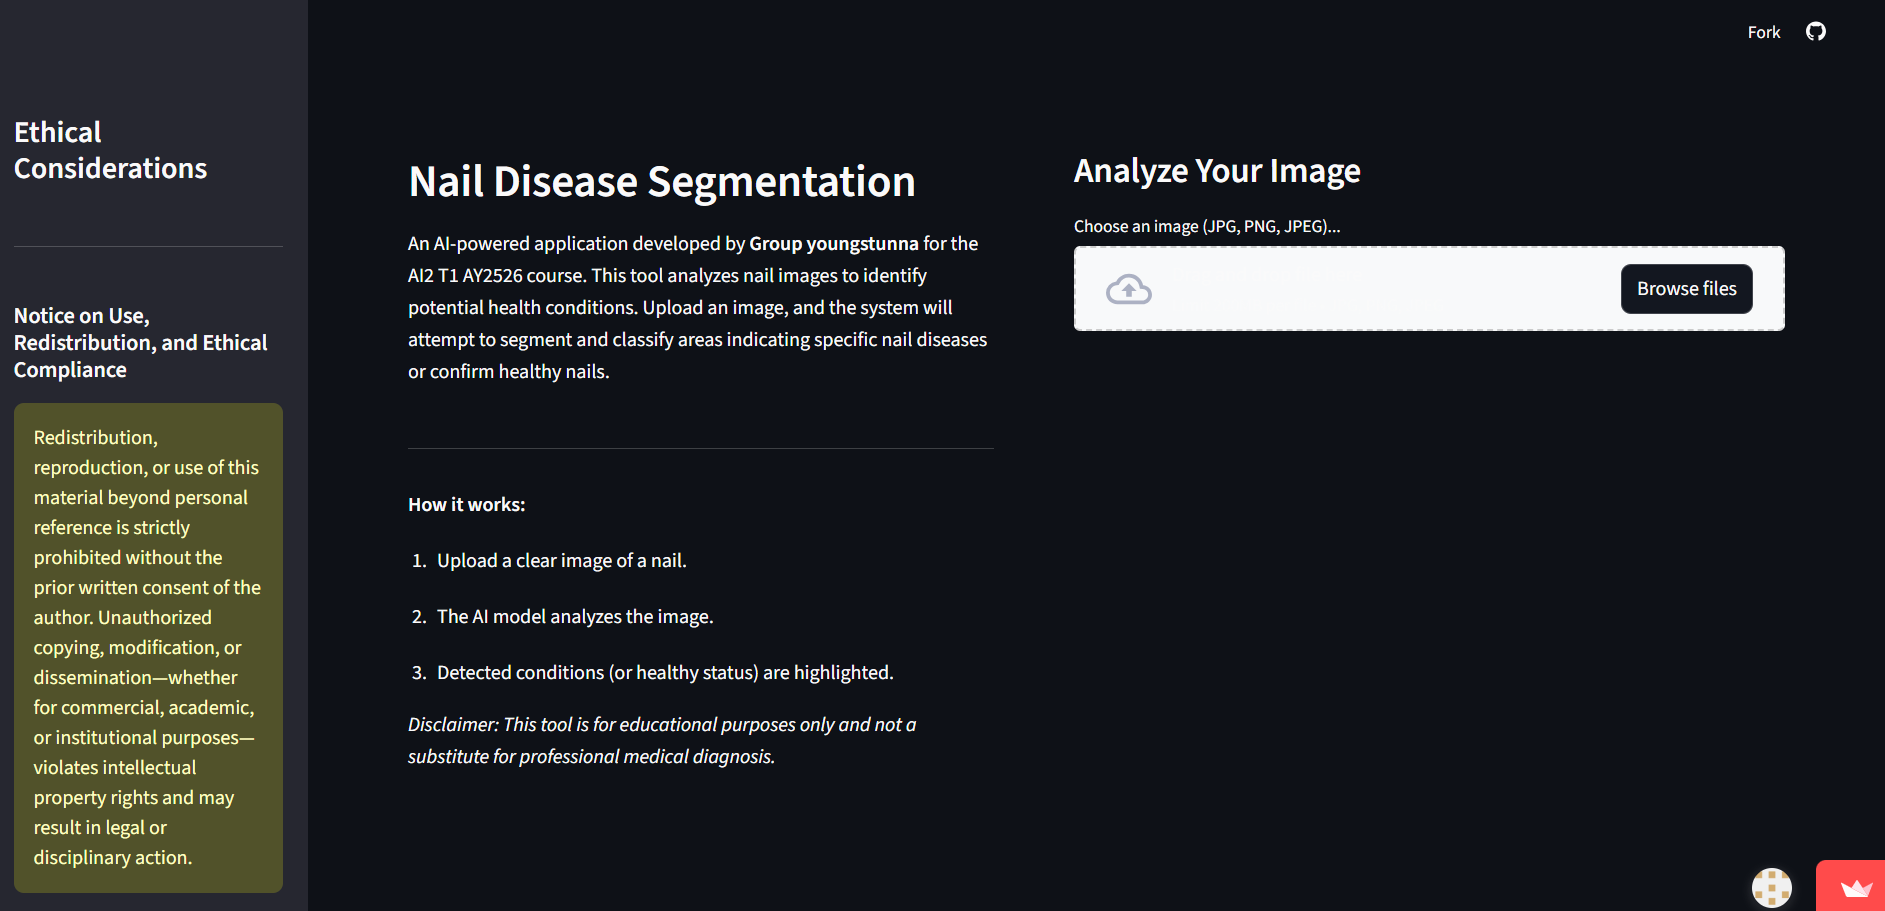

# ⚠️ Notice

## This material is the intellectual property of <font color="cyan">Dr. Lysa V. Comia.</font>  


## 📌 Notice on Use, Redistribution, and Ethical Compliance  

Redistribution, reproduction, or use of this material beyond personal reference is **strictly prohibited** without the prior written consent of the author. Unauthorized copying, modification, or dissemination—whether for commercial, academic, or institutional purposes—violates intellectual property rights and may result in legal or disciplinary action.  

---

### 🔒 AI Governance and Ethics Considerations  
This work must **not** be used in ways that:  
- ❌ **Compromise data privacy** or violate data protection regulations (e.g., GDPR, Philippine Data Privacy Act).  
- ❌ **Perpetuate bias or discrimination** by misusing algorithms, datasets, or results.  
- ❌ **Enable harmful applications**, including surveillance, profiling, or uses that undermine human rights.  
- ❌ **Misrepresent authorship or credit**, such as plagiarism or omission of proper citations.  

---

### ✅ Responsible Use Principles  
Users are expected to follow responsible research and innovation practices, ensuring that any derivative work is:  
- **Transparent** → Clear acknowledgment of sources and methodology.  
- **Accountable** → Proper attribution and disclosure of limitations.  
- **Beneficial to society** → Applications that align with ethical standards and do not cause harm.  

---

📢 For **any intended use** (academic, research, or practical), prior written approval must be obtained from the author to ensure compliance with both **legal requirements** and **ethical AI practices**.  
